In [1]:
import pandas as pd

In [2]:
import numpy as np

In [181]:
df=pd.read_csv("Loan.csv")

In [182]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 37 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ApplicationDate             20000 non-null  object 
 1   Age                         20000 non-null  int64  
 2   AnnualIncome                20000 non-null  int64  
 3   CreditScore                 20000 non-null  int64  
 4   EmploymentStatus            20000 non-null  object 
 5   EducationLevel              20000 non-null  object 
 6   Experience                  20000 non-null  int64  
 7   LoanAmount                  20000 non-null  int64  
 8   LoanDuration                20000 non-null  int64  
 9   MaritalStatus               20000 non-null  object 
 10  NumberOfDependents          20000 non-null  int64  
 11  HomeOwnershipStatus         20000 non-null  object 
 12  MonthlyDebtPayments         20000 non-null  int64  
 13  CreditCardUtilizationRate   200

In [183]:
df.shape

(20000, 37)

In [7]:
df.isna().sum()

ApplicationDate               0
Age                           0
AnnualIncome                  0
CreditScore                   0
EmploymentStatus              0
EducationLevel                0
Experience                    0
LoanAmount                    0
LoanDuration                  0
MaritalStatus                 0
NumberOfDependents            0
HomeOwnershipStatus           0
MonthlyDebtPayments           0
CreditCardUtilizationRate     0
NumberOfOpenCreditLines       0
NumberOfCreditInquiries       0
DebtToIncomeRatio             0
BankruptcyHistory             0
LoanPurpose                   0
PreviousLoanDefaults          0
PaymentHistory                0
LengthOfCreditHistory         0
SavingsAccountBalance         0
CheckingAccountBalance        0
TotalAssets                   0
TotalLiabilities              0
MonthlyIncome                 0
UtilityBillsPaymentHistory    0
JobTenure                     0
NetWorth                      0
BaseInterestRate              0
Interest

In [184]:
df.isna().sum().sum()

np.int64(0)

In [10]:
df.duplicated().sum()

np.int64(0)

In [185]:
df.dtypes

ApplicationDate                object
Age                             int64
AnnualIncome                    int64
CreditScore                     int64
EmploymentStatus               object
EducationLevel                 object
Experience                      int64
LoanAmount                      int64
LoanDuration                    int64
MaritalStatus                  object
NumberOfDependents              int64
HomeOwnershipStatus            object
MonthlyDebtPayments             int64
CreditCardUtilizationRate     float64
NumberOfOpenCreditLines         int64
NumberOfCreditInquiries         int64
DebtToIncomeRatio             float64
BankruptcyHistory               int64
LoanPurpose                    object
PreviousLoanDefaults            int64
PaymentHistory                  int64
LengthOfCreditHistory           int64
SavingsAccountBalance           int64
CheckingAccountBalance          int64
TotalAssets                     int64
TotalLiabilities                int64
MonthlyIncom

In [ ]:
df['LoanApproved'].value_counts()

LoanApproved
0    15220
1     4780
Name: count, dtype: int64

In [186]:
df['LoanApproved'].value_counts(normalize=True)

LoanApproved
0    0.761
1    0.239
Name: proportion, dtype: float64

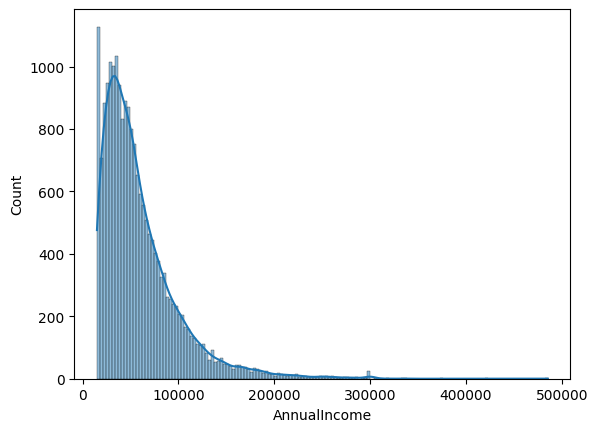

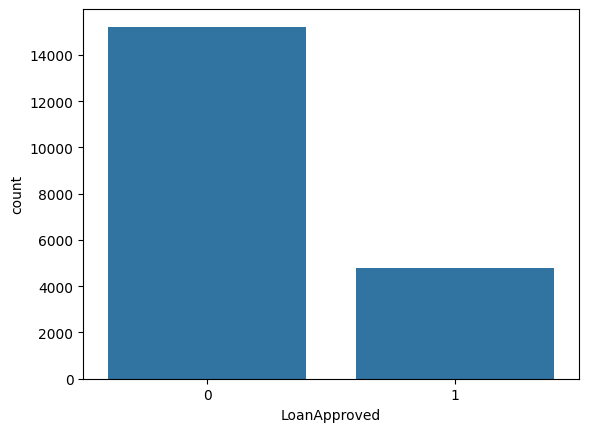

In [187]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df['AnnualIncome'], kde=True)
plt.show()

sns.countplot(x='LoanApproved', data=df)
plt.show()

The Annual Income distribution is highly right-skewed, indicating that most applicants fall in lower income brackets, while a small proportion of applicants have significantly higher incomes(outliers).

The dataset is imbalanced, with significantly more loan rejections than approvals.

In [188]:
# ML models don’t like skewed data
# You may need log transformation
df['Log_Income'] = np.log1p(df['AnnualIncome'])

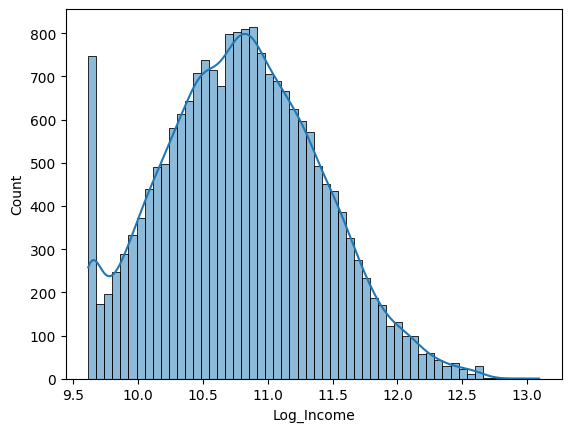

In [189]:

sns.histplot(df['Log_Income'], kde=True)
plt.show()

In [190]:
df.groupby('LoanApproved').mean(numeric_only=True)

,Age,AnnualIncome,CreditScore,Experience,LoanAmount,LoanDuration,NumberOfDependents,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,RiskScore,Log_Income
LoanApproved,,,,,,,,,,,,,,,,,,,,,
0,38.834034,45641.460907,567.554205,16.630092,26684.996386,55.363995,1.515966,463.783180,0.287318,3.027989,...,3775.639099,0.799694,4.996386,59878.028055,0.244045,0.246244,981.268113,0.480130,54.106307,10.600499
1,42.677406,102210.551464,584.534100,20.365063,19144.709414,49.895397,1.521548,424.074059,0.283397,3.008577,...,8445.414923,0.800629,5.022594,111829.035565,0.223457,0.216393,689.799237,0.153987,40.133389,11.426095


In [191]:
df.groupby('LoanApproved')[['AnnualIncome', 'CreditScore']].mean()

,AnnualIncome,CreditScore
LoanApproved,,
0,45641.460907,567.554205
1,102210.551464,584.534100


Applicants with higher income and credit score have a significantly higher probability of loan approval.

if trained directly
Model may predict always 0 (rejected)
Accuracy may look high but is misleading

In [11]:
from sklearn.utils import resample

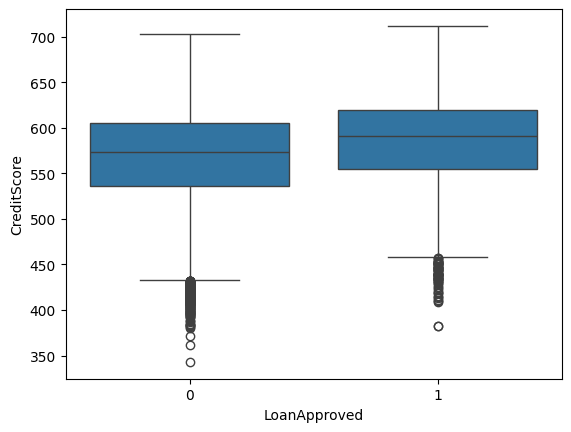

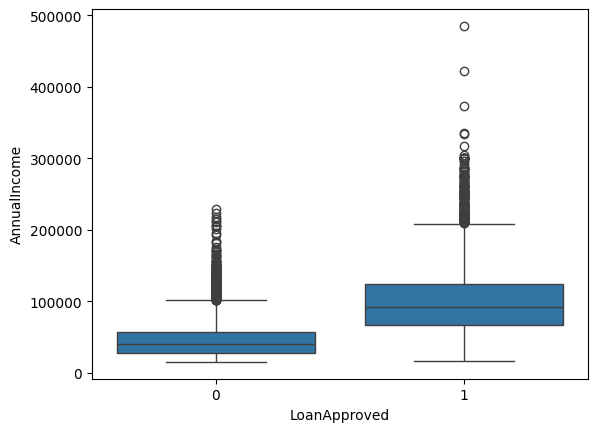

In [12]:
sns.boxplot(x='LoanApproved', y='CreditScore', data=df)
plt.show()

sns.boxplot(x='LoanApproved', y='AnnualIncome', data=df)
plt.show()

Credit score is a strong predictor
Even small increase in score improves approval chances


Some low credit scores are still approved → means:
Other factors (income, loan amount, etc.) also matter

In [192]:
df['ApplicationDate'] = pd.to_datetime(df['ApplicationDate'])

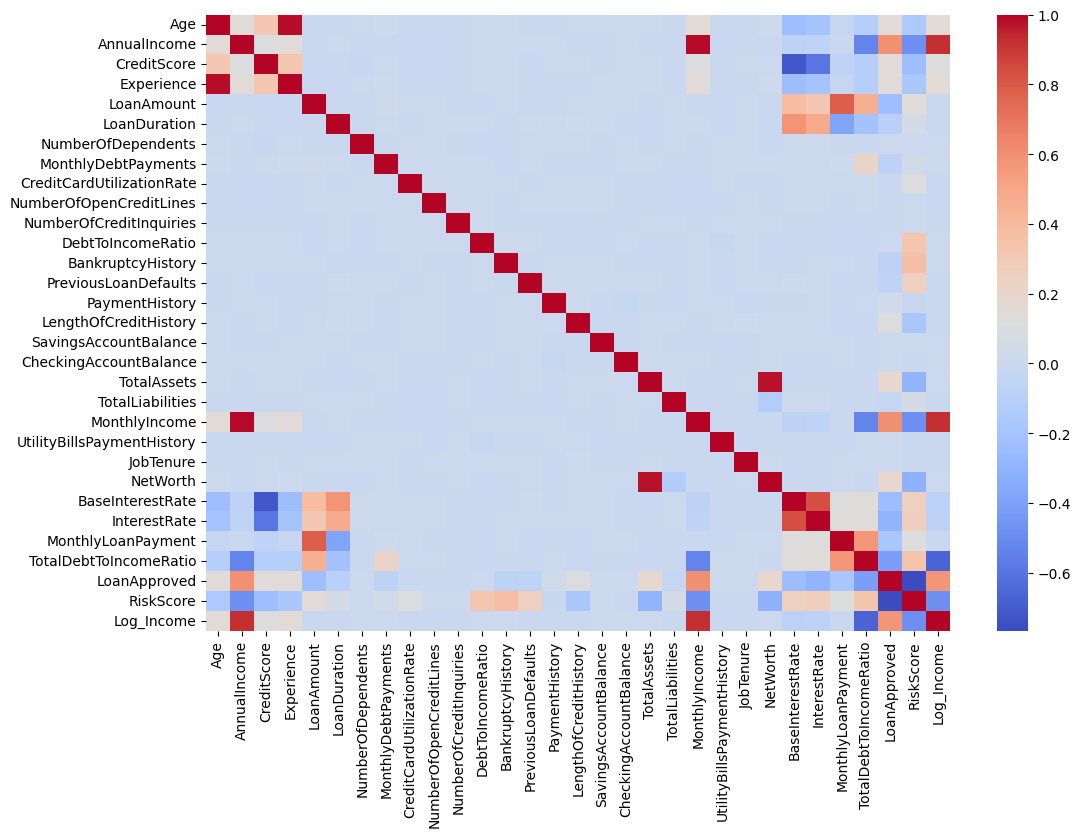

In [14]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.show()

In [193]:
corr = df.corr(numeric_only=True)

# correlation with target
corr_target = corr['LoanApproved'].sort_values(ascending=False)

print(corr_target)

LoanApproved                  1.000000
MonthlyIncome                 0.604101
AnnualIncome                  0.597900
Log_Income                    0.577045
NetWorth                      0.187892
TotalAssets                   0.184011
CreditScore                   0.142000
Age                           0.141029
Experience                    0.140755
LengthOfCreditHistory         0.105949
PaymentHistory                0.030804
JobTenure                     0.004997
UtilityBillsPaymentHistory    0.003303
NumberOfDependents            0.001717
SavingsAccountBalance         0.000961
CheckingAccountBalance        0.000660
DebtToIncomeRatio             0.000034
NumberOfOpenCreditLines      -0.004769
NumberOfCreditInquiries      -0.005885
CreditCardUtilizationRate    -0.010466
TotalLiabilities             -0.029434
PreviousLoanDefaults         -0.065343
MonthlyDebtPayments          -0.070415
BankruptcyHistory            -0.070751
LoanDuration                 -0.094558
MonthlyLoanPayment       

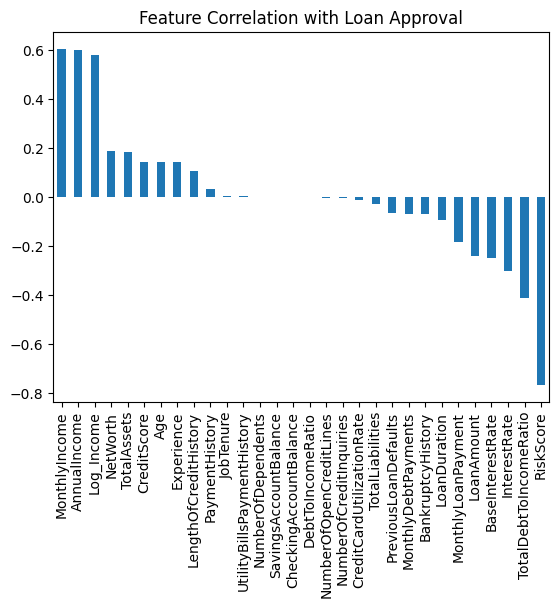

In [16]:
import matplotlib.pyplot as plt

corr_target.drop('LoanApproved').plot(kind='bar')
plt.title("Feature Correlation with Loan Approval")
plt.show()

What your correlation plot is telling:

From your feature vs LoanApproved graph:

->Strong positive features (TOP ones)
MonthlyIncome
AnnualIncome
Log_Income
NetWorth
TotalAssets

Meaning:
Higher financial strength → higher approval chances

Strong negative features:
RiskScore (VERY strong negative)
TotalDebtToIncomeRatio
InterestRate
MonthlyLoanPayment

Meaning:
Higher risk / higher debt burden → lower approval chances

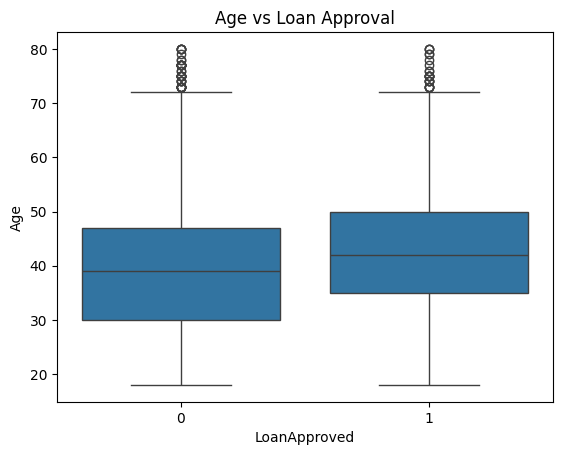

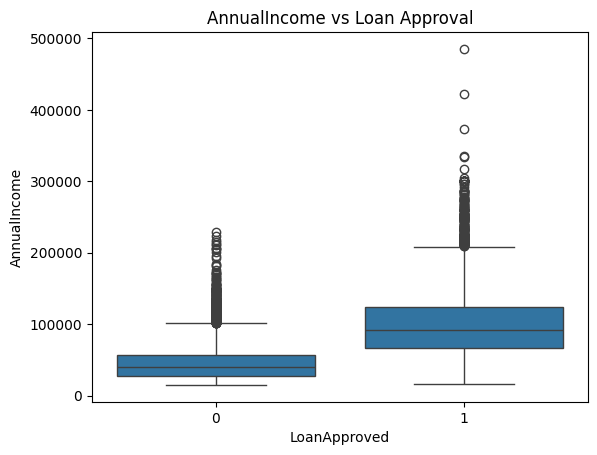

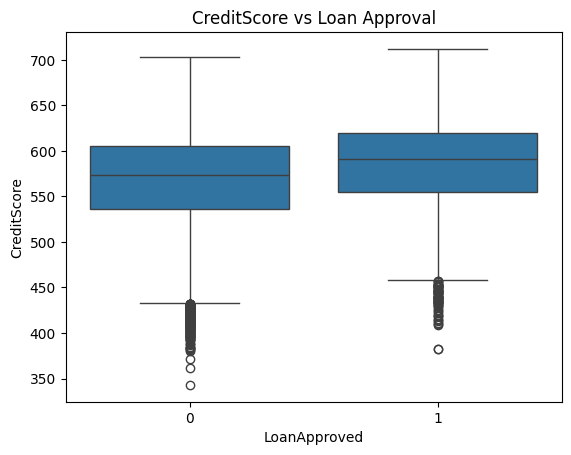

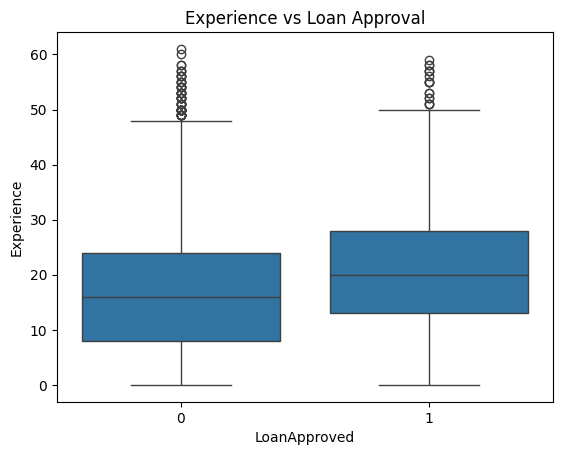

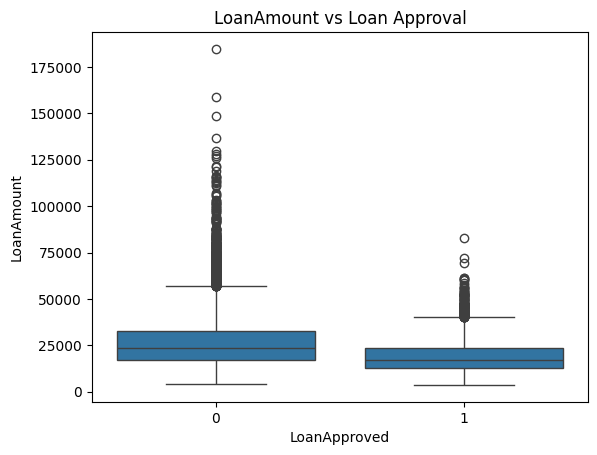

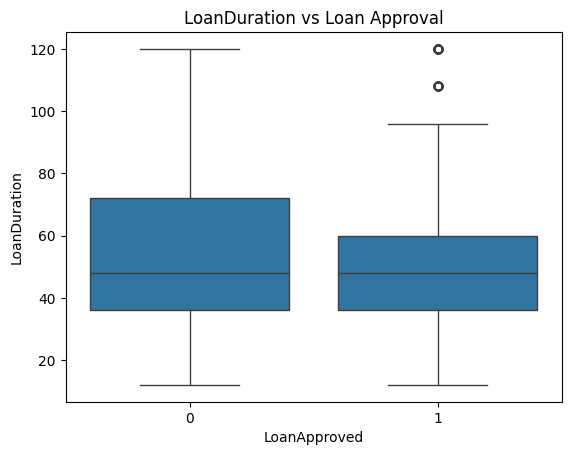

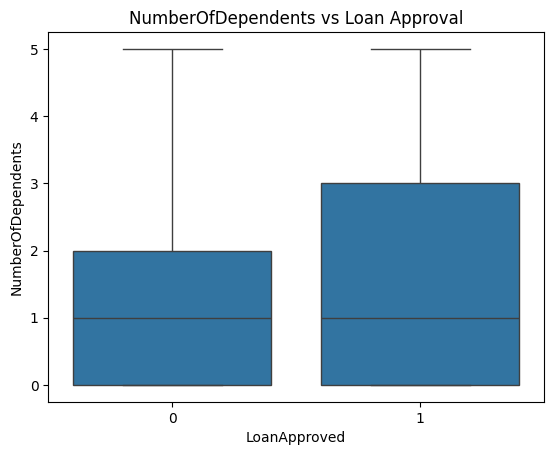

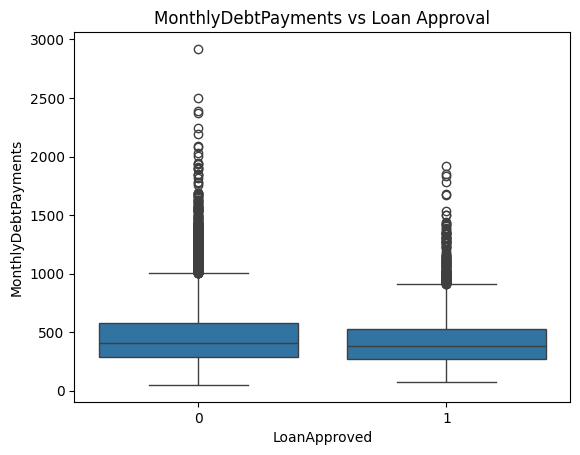

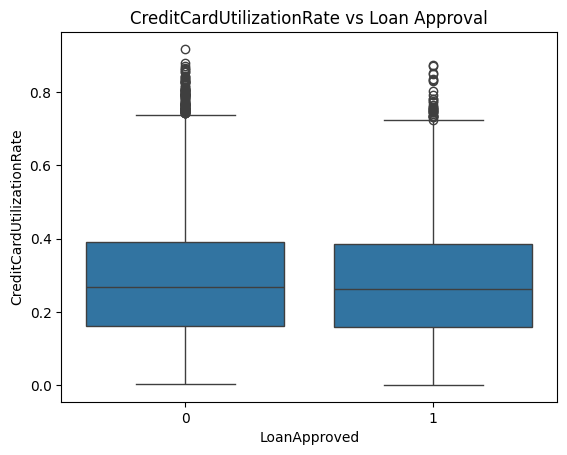

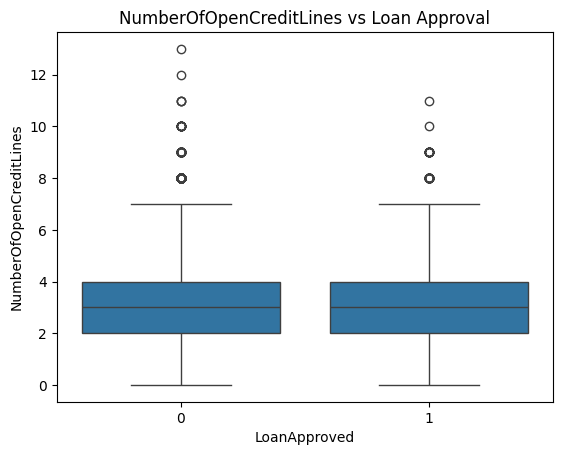

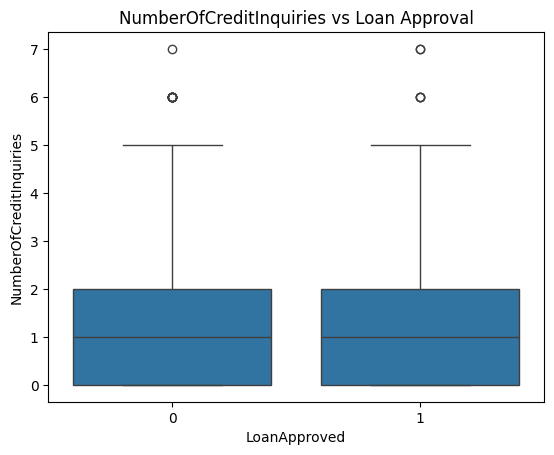

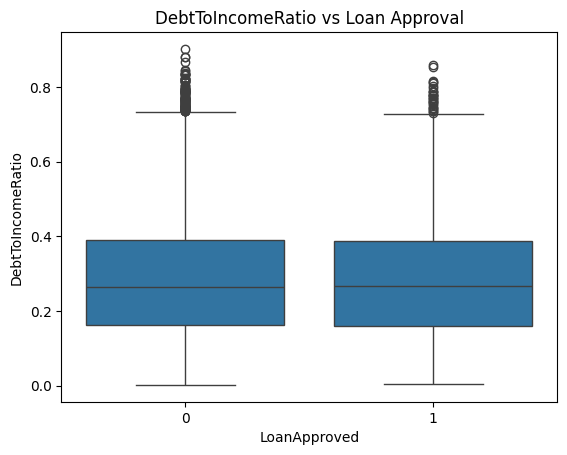

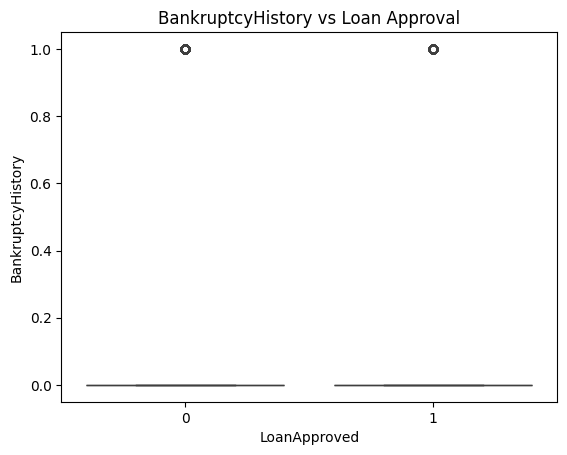

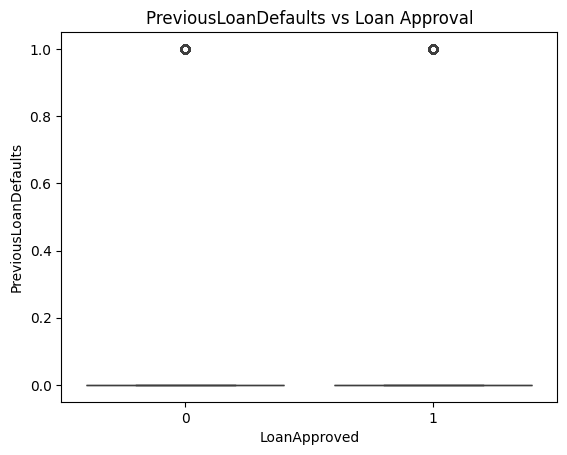

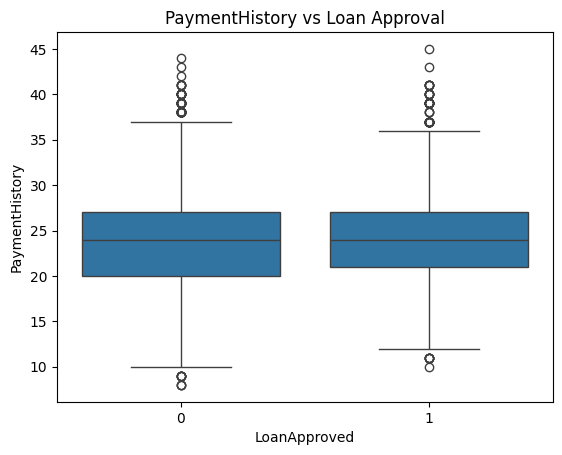

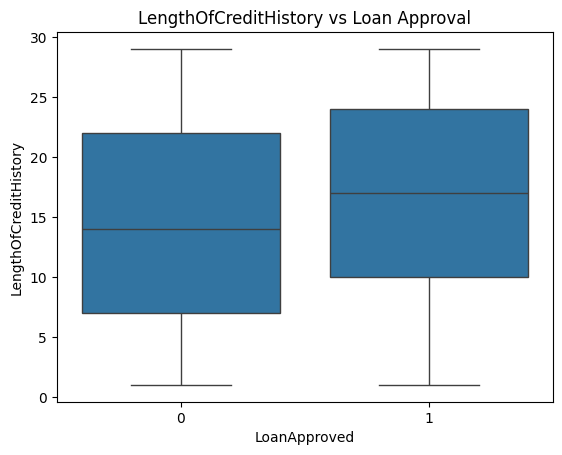

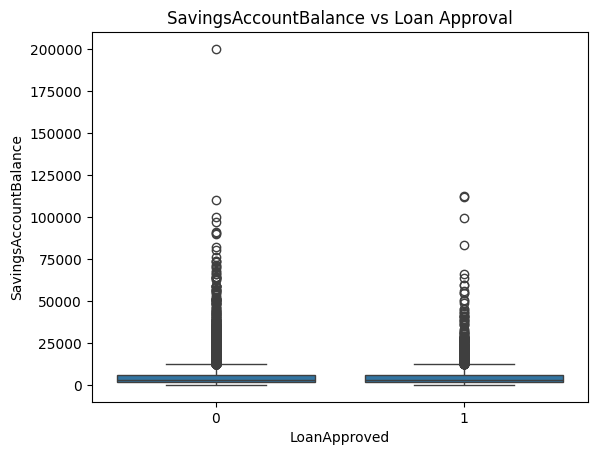

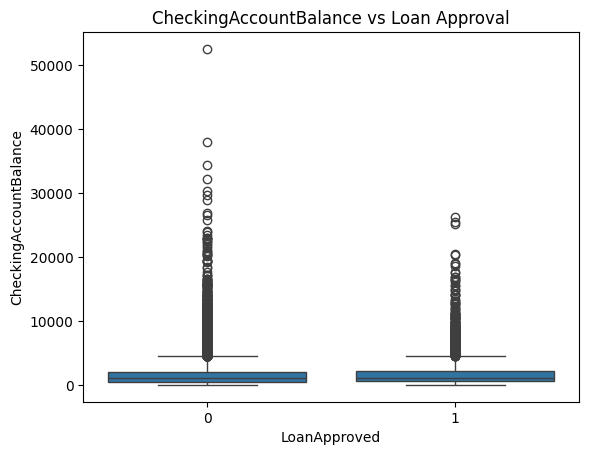

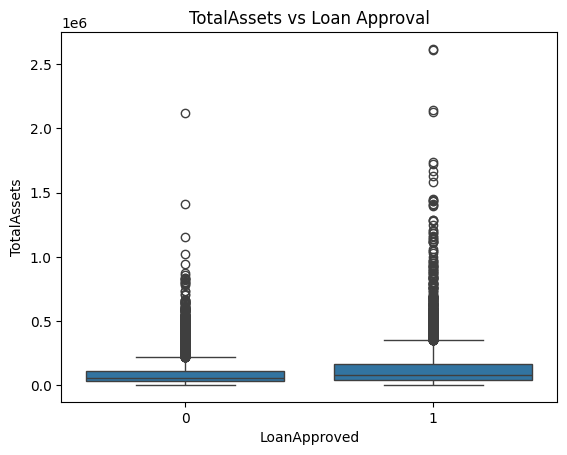

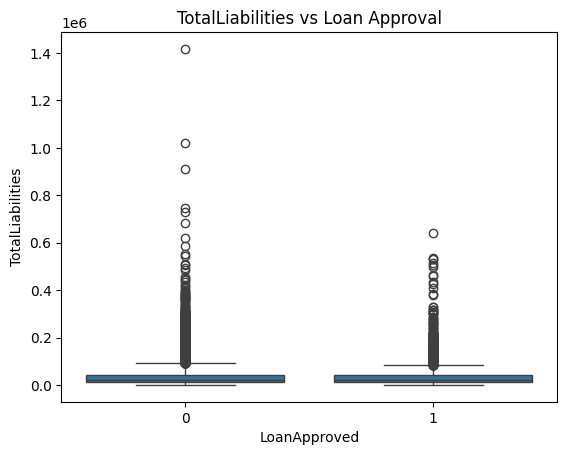

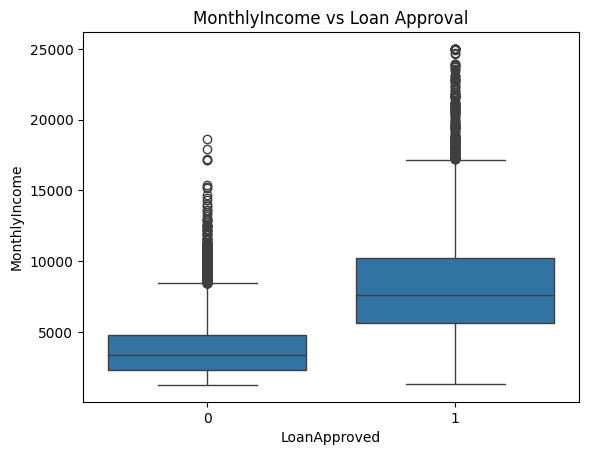

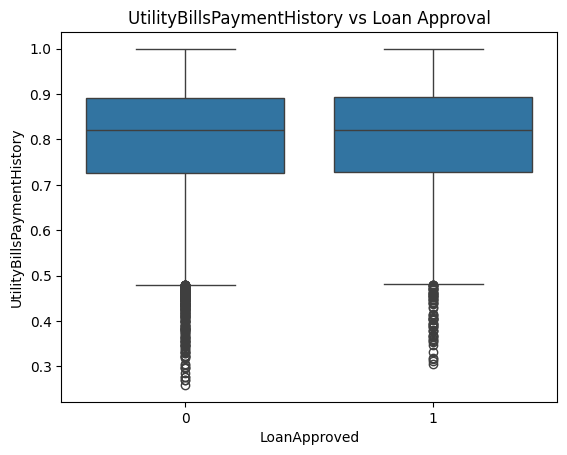

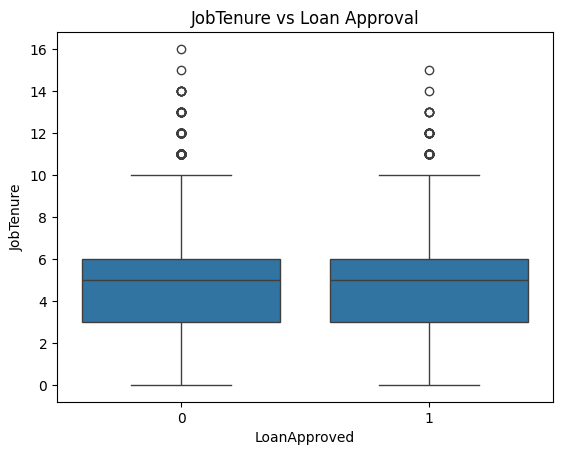

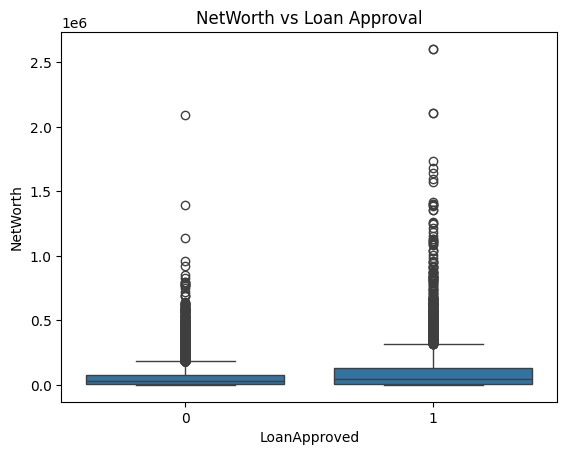

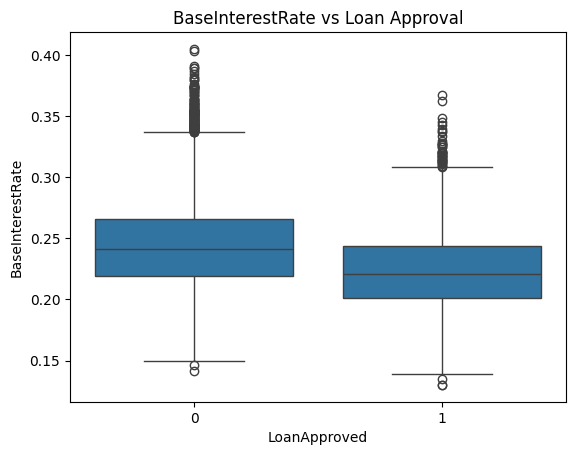

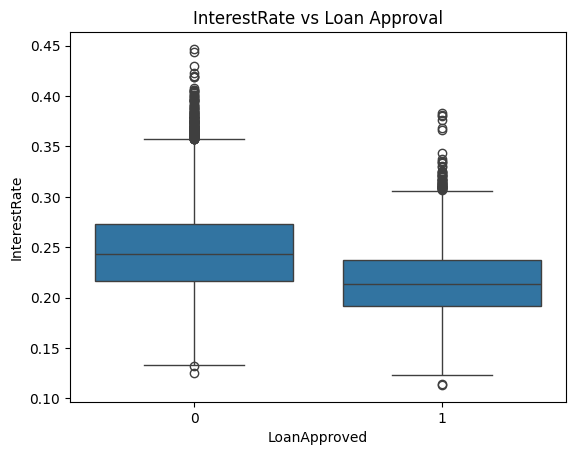

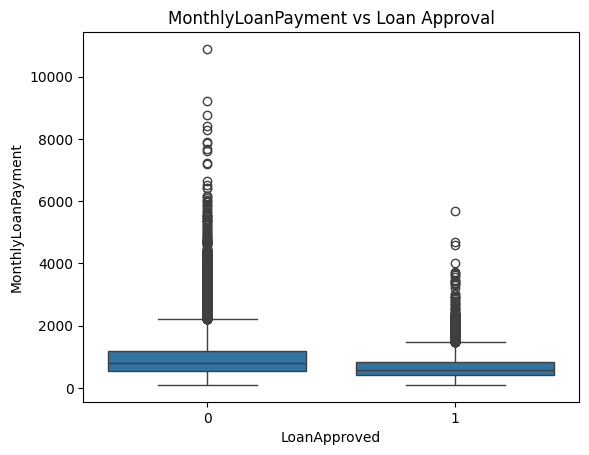

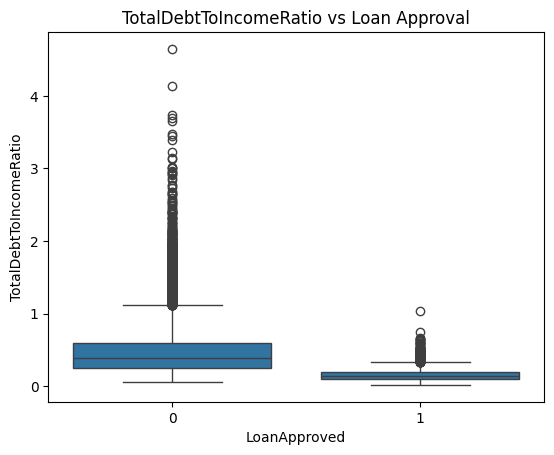

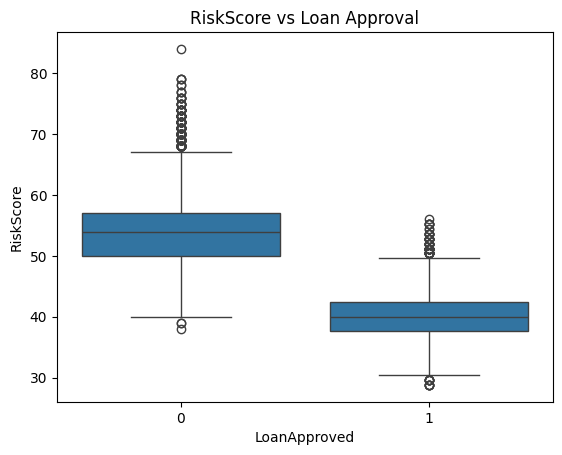

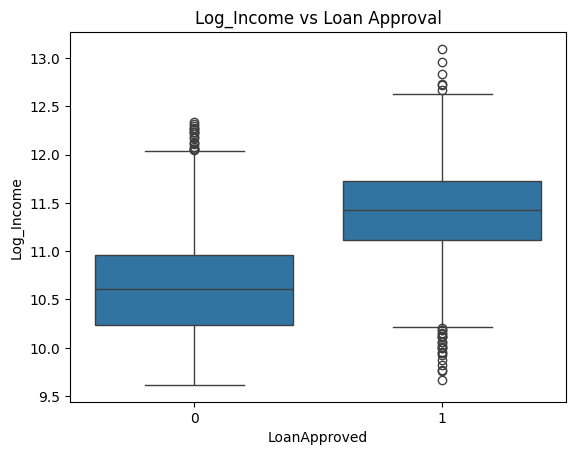

In [17]:
num_cols = df.select_dtypes(include=['int64','float64']).columns

import seaborn as sns
import matplotlib.pyplot as plt

for col in num_cols:
    if col != 'LoanApproved':
        plt.figure()
        sns.boxplot(x='LoanApproved', y=col, data=df)
        plt.title(f"{col} vs Loan Approval")
        plt.show()

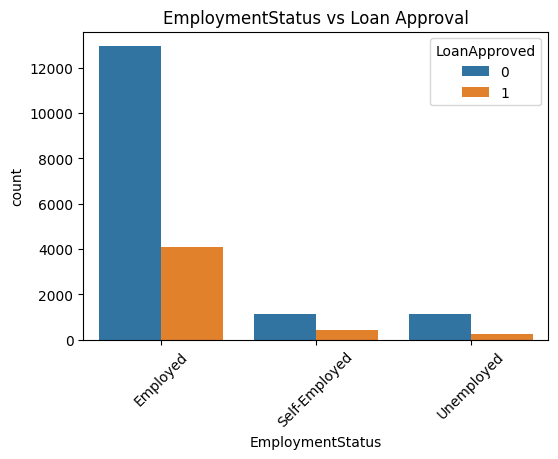


Approval Ratio for EmploymentStatus:

LoanApproved             0         1
EmploymentStatus                    
Employed          0.759979  0.240021
Self-Employed     0.721551  0.278449
Unemployed        0.818116  0.181884

--------------------------------------------------


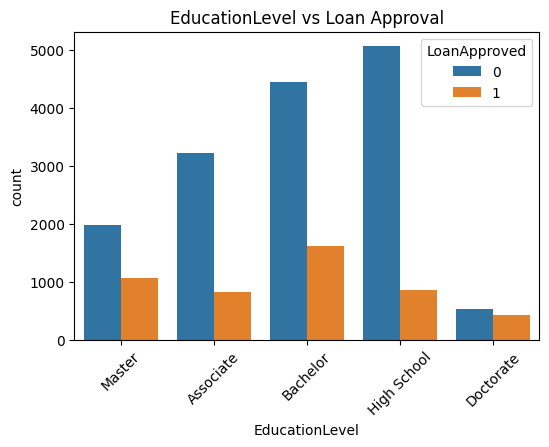


Approval Ratio for EducationLevel:

LoanApproved           0         1
EducationLevel                    
Associate       0.795736  0.204264
Bachelor        0.733565  0.266435
Doctorate       0.559748  0.440252
High School     0.855619  0.144381
Master          0.649180  0.350820

--------------------------------------------------


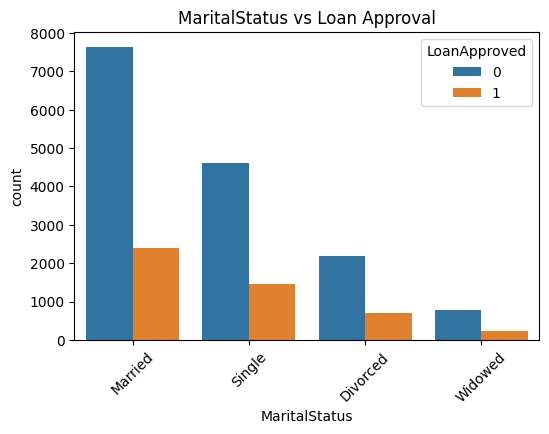


Approval Ratio for MaritalStatus:

LoanApproved          0         1
MaritalStatus                    
Divorced       0.755031  0.244969
Married        0.761478  0.238522
Single         0.760612  0.239388
Widowed        0.775776  0.224224

--------------------------------------------------


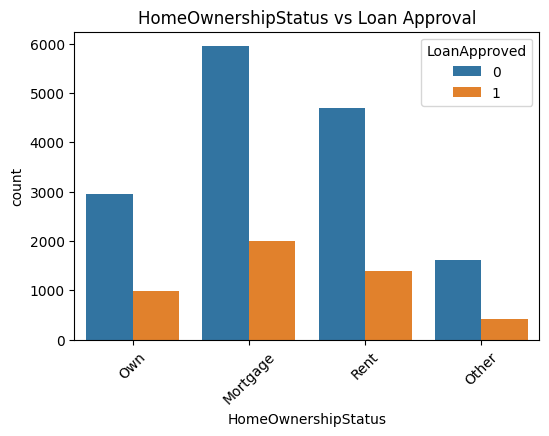


Approval Ratio for HomeOwnershipStatus:

LoanApproved                0         1
HomeOwnershipStatus                    
Mortgage             0.748457  0.251543
Other                0.795187  0.204813
Own                  0.751143  0.248857
Rent                 0.772302  0.227698

--------------------------------------------------


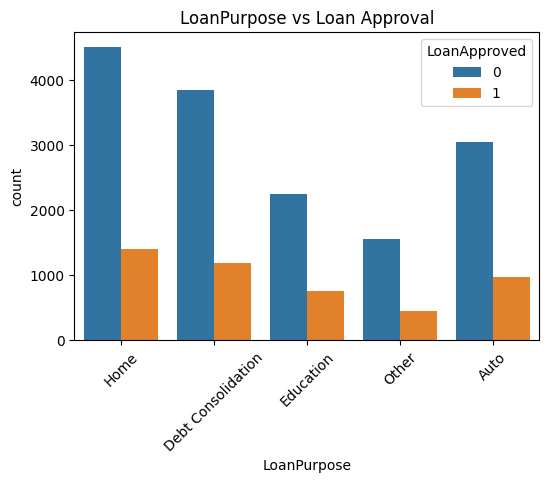


Approval Ratio for LoanPurpose:

LoanApproved               0         1
LoanPurpose                           
Auto                0.757313  0.242687
Debt Consolidation  0.764870  0.235130
Education           0.747008  0.252992
Home                0.762025  0.237975
Other               0.776670  0.223330

--------------------------------------------------


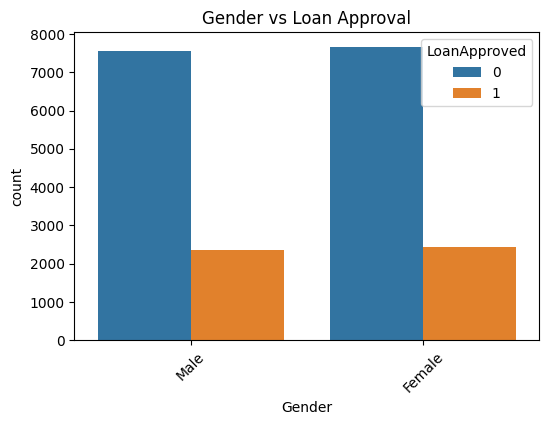


Approval Ratio for Gender:

LoanApproved         0         1
Gender                          
Female        0.759116  0.240884
Male          0.762919  0.237081

--------------------------------------------------


In [194]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, hue='LoanApproved', data=df)
    plt.title(f"{col} vs Loan Approval")
    plt.xticks(rotation=45)
    plt.show()

    # ratio table
    ratio = df.groupby(col)['LoanApproved'].value_counts(normalize=True).unstack()
    print(f"\nApproval Ratio for {col}:\n")
    print(ratio)
    print("\n" + "-"*50)

In [195]:
df.pivot_table(values='LoanApproved', index='EducationLevel', aggfunc='mean')

,LoanApproved
EducationLevel,
Associate,0.204264
Bachelor,0.266435
Doctorate,0.440252
High School,0.144381
Master,0.350820


In [196]:
approval_rate = df.groupby(col)['LoanApproved'].mean()
print(approval_rate)

Gender
Female    0.240884
Male      0.237081
Name: LoanApproved, dtype: float64


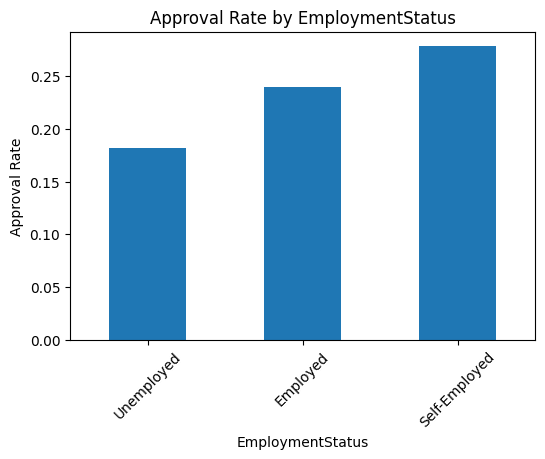

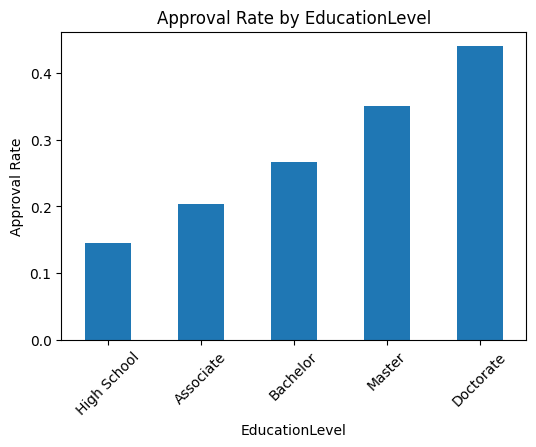

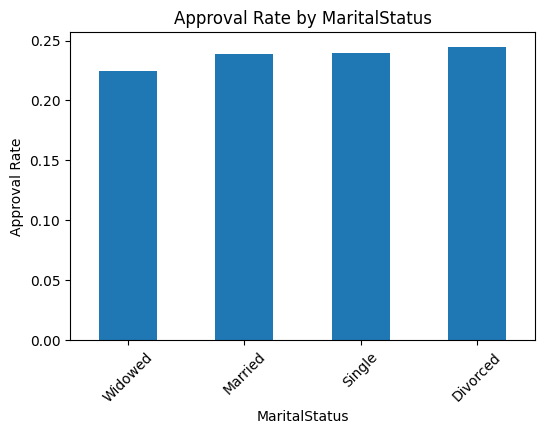

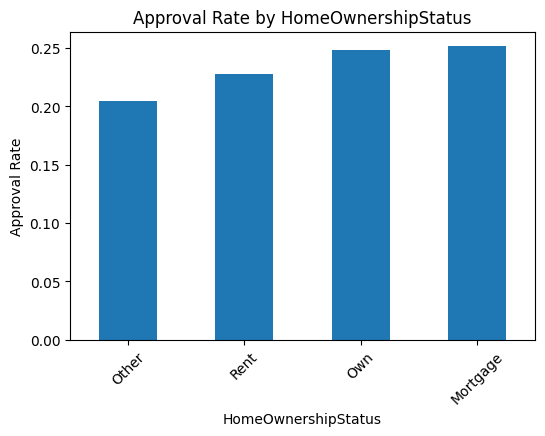

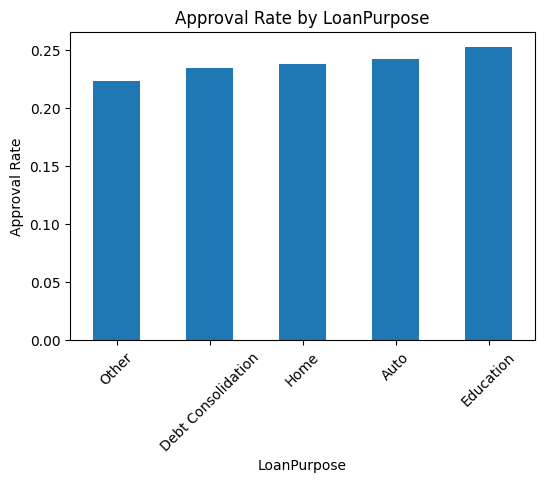

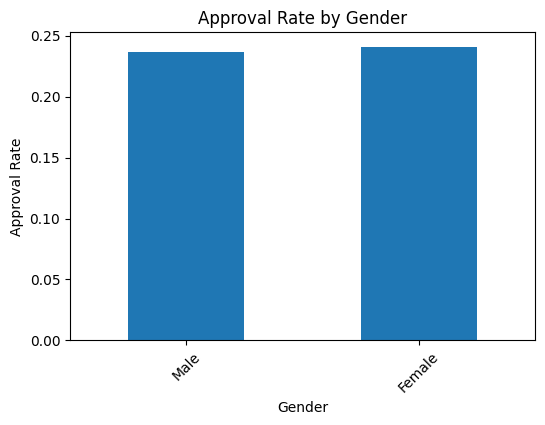

In [21]:
for col in cat_cols:
    plt.figure(figsize=(6,4))

    approval_rate = df.groupby(col)['LoanApproved'].mean().sort_values()

    approval_rate.plot(kind='bar')
    plt.title(f"Approval Rate by {col}")
    plt.ylabel("Approval Rate")
    plt.xticks(rotation=45)

    plt.show()

In [197]:
df['ApplicationYear'] = df['ApplicationDate'].dt.year
df['ApplicationMonth'] = df['ApplicationDate'].dt.month

In [198]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [199]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

num_cols = df.select_dtypes(include=['int64','float64']).columns

df[num_cols] = scaler.fit_transform(df[num_cols])

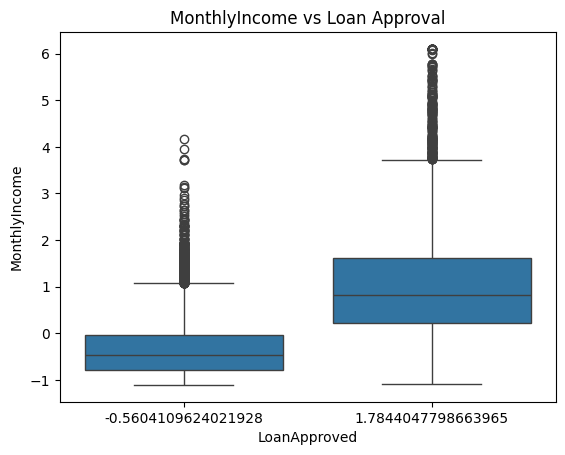

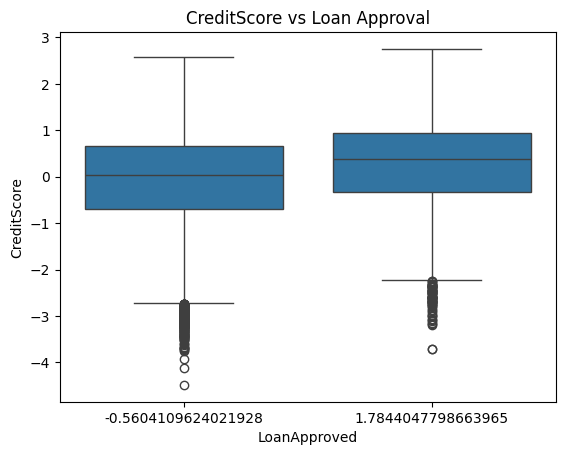

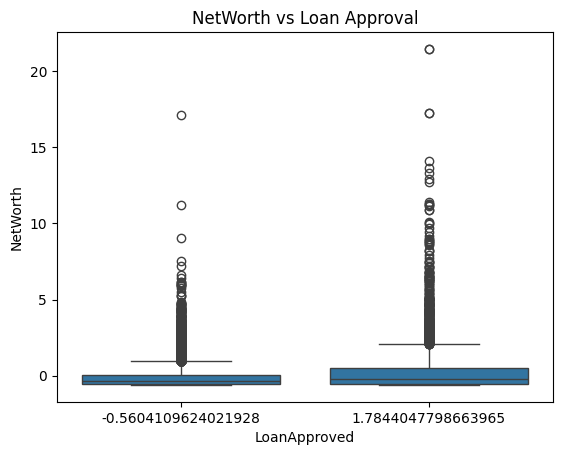

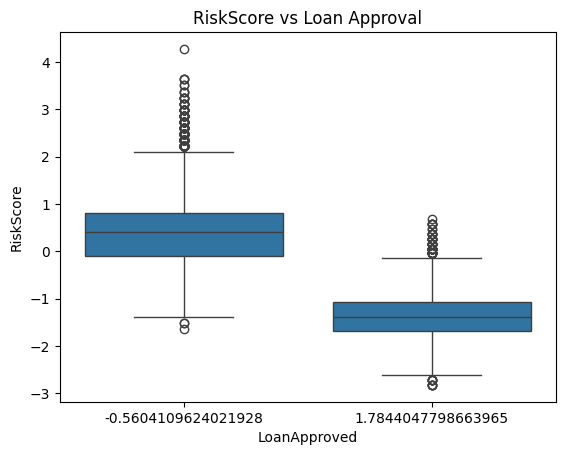

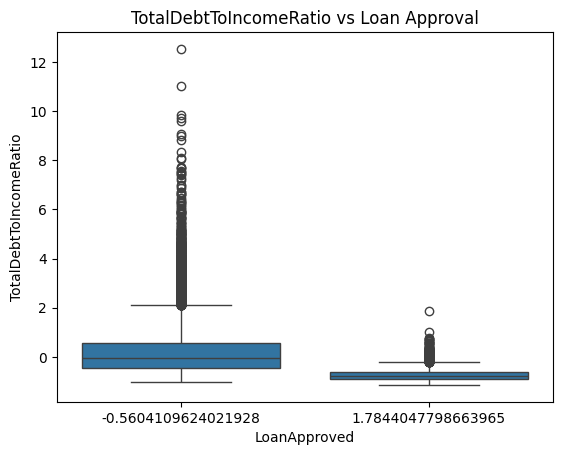

In [200]:
features = ['MonthlyIncome','CreditScore','NetWorth','RiskScore','TotalDebtToIncomeRatio']

for col in features:
    plt.figure()
    sns.boxplot(x='LoanApproved', y=col, data=df)
    plt.title(f"{col} vs Loan Approval")
    plt.show()

TOP 5 FEATURES in APPROVAL/REJECTION

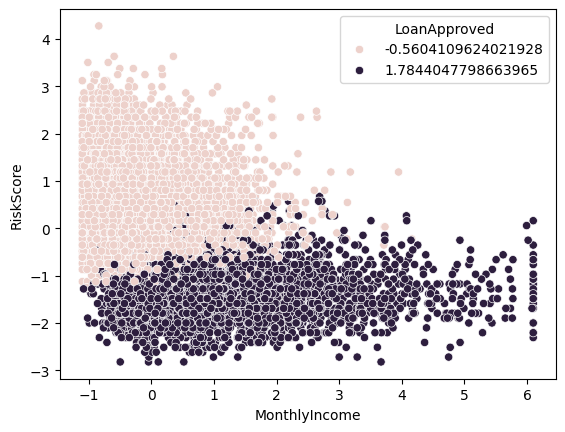

In [26]:
sns.scatterplot(x='MonthlyIncome', y='RiskScore', hue='LoanApproved', data=df)
plt.show()

“Correlation analysis revealed that financial strength indicators such as Monthly Income, Annual Income, Net Worth, and Total Assets have a strong positive relationship with loan approval. Conversely, Risk Score and Debt-to-Income Ratio exhibit strong negative correlations, indicating that higher financial risk reduces approval probability.”

CHECKING SKEWNESS IN COLUMNS

In [201]:
df.skew(numeric_only=True).sort_values(ascending=False)

SavingsAccountBalance         6.060099
TotalLiabilities              5.848874
NetWorth                      5.599844
TotalAssets                   5.311326
CheckingAccountBalance        4.746142
BankruptcyHistory             4.017672
MonthlyLoanPayment            3.081845
PreviousLoanDefaults          2.665941
TotalDebtToIncomeRatio        2.574494
EmploymentStatus              2.455244
AnnualIncome                  2.088948
MonthlyIncome                 1.992929
LoanAmount                    1.833688
MonthlyDebtPayments           1.653435
LoanApproved                  1.224086
NumberOfCreditInquiries       1.012065
LoanDuration                  0.651330
NumberOfDependents            0.639919
CreditCardUtilizationRate     0.601131
NumberOfOpenCreditLines       0.599662
DebtToIncomeRatio             0.593858
InterestRate                  0.485491
BaseInterestRate              0.461850
JobTenure                     0.436452
Experience                    0.339981
PaymentHistory           

Data is not symmetric
Few extreme values dominate
👉 Effect on models:
Model	Effect of skewness
Logistic Regression      	⚠️ affected
Linear models	            ⚠️ affected
Distance-based (KNN)	    ⚠️ affected
Tree models (RF, XGBoost)	✅ mostly fine

In [47]:
skewed_cols = df.skew(numeric_only=True)
skewed_cols = skewed_cols[skewed_cols > 1].index

for col in skewed_cols:
    df[col] = np.log1p(df[col])

C:\Users\pragy\AppData\Roaming\Python\Python311\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [48]:
df.skew(numeric_only=True).sort_values(ascending=False)

BankruptcyHistory             4.017672
PreviousLoanDefaults          2.665941
EmploymentStatus              2.118022
LoanApproved                  1.224086
NetWorth                      1.098847
SavingsAccountBalance         0.878822
TotalLiabilities              0.806252
NumberOfCreditInquiries       0.798443
CheckingAccountBalance        0.714704
TotalAssets                   0.698640
LoanDuration                  0.651330
NumberOfDependents            0.639919
CreditCardUtilizationRate     0.601131
NumberOfOpenCreditLines       0.599662
DebtToIncomeRatio             0.593858
InterestRate                  0.485491
BaseInterestRate              0.461850
JobTenure                     0.436452
Experience                    0.339981
PaymentHistory                0.213465
MaritalStatus                 0.202967
Age                           0.185964
Log_Income                    0.158672
EducationLevel                0.083093
HomeOwnershipStatus           0.071497
LoanPurpose              

In [202]:
skew_vals = df.skew(numeric_only=True)

skewed_cols = skew_vals[skew_vals > 1].index

print(skewed_cols)

Index(['AnnualIncome', 'EmploymentStatus', 'LoanAmount', 'MonthlyDebtPayments',
       'NumberOfCreditInquiries', 'BankruptcyHistory', 'PreviousLoanDefaults',
       'SavingsAccountBalance', 'CheckingAccountBalance', 'TotalAssets',
       'TotalLiabilities', 'MonthlyIncome', 'NetWorth', 'MonthlyLoanPayment',
       'TotalDebtToIncomeRatio', 'LoanApproved'],
      dtype='object')


In [203]:
import numpy as np

for col in skewed_cols:
    if (df[col] > 0).all():   # important condition
        df[col] = np.log1p(df[col])

In [204]:
df.skew(numeric_only=True).sort_values(ascending=False)

SavingsAccountBalance         6.060099
TotalLiabilities              5.848874
NetWorth                      5.599844
TotalAssets                   5.311326
CheckingAccountBalance        4.746142
BankruptcyHistory             4.017672
MonthlyLoanPayment            3.081845
PreviousLoanDefaults          2.665941
TotalDebtToIncomeRatio        2.574494
EmploymentStatus              2.455244
AnnualIncome                  2.088948
MonthlyIncome                 1.992929
LoanAmount                    1.833688
MonthlyDebtPayments           1.653435
LoanApproved                  1.224086
NumberOfCreditInquiries       1.012065
LoanDuration                  0.651330
NumberOfDependents            0.639919
CreditCardUtilizationRate     0.601131
NumberOfOpenCreditLines       0.599662
DebtToIncomeRatio             0.593858
InterestRate                  0.485491
BaseInterestRate              0.461850
JobTenure                     0.436452
Experience                    0.339981
PaymentHistory           

In [205]:
import numpy as np

cols_to_log = [
    'SavingsAccountBalance',
    'TotalLiabilities',
    'NetWorth',
    'TotalAssets',
    'CheckingAccountBalance',
    'MonthlyLoanPayment',
    'TotalDebtToIncomeRatio',
    'AnnualIncome'
]

for col in cols_to_log:
    if (df[col] > 0).all():
        df[col] = np.log1p(df[col])

In [206]:
df[['AnnualIncome']].head()

,AnnualIncome
0,-0.476172
1,-0.482095
2,-0.456940
3,0.245912
4,1.093004


In [207]:
df['AnnualIncome'].skew()

np.float64(2.088947958524819)

In [208]:
df.skew(numeric_only=True).sort_values(ascending=False)

SavingsAccountBalance         6.060099
TotalLiabilities              5.848874
NetWorth                      5.599844
TotalAssets                   5.311326
CheckingAccountBalance        4.746142
BankruptcyHistory             4.017672
MonthlyLoanPayment            3.081845
PreviousLoanDefaults          2.665941
TotalDebtToIncomeRatio        2.574494
EmploymentStatus              2.455244
AnnualIncome                  2.088948
MonthlyIncome                 1.992929
LoanAmount                    1.833688
MonthlyDebtPayments           1.653435
LoanApproved                  1.224086
NumberOfCreditInquiries       1.012065
LoanDuration                  0.651330
NumberOfDependents            0.639919
CreditCardUtilizationRate     0.601131
NumberOfOpenCreditLines       0.599662
DebtToIncomeRatio             0.593858
InterestRate                  0.485491
BaseInterestRate              0.461850
JobTenure                     0.436452
Experience                    0.339981
PaymentHistory           

In [209]:
import numpy as np

cols_to_transform = [
    'SavingsAccountBalance',
    'TotalLiabilities',
    'NetWorth',
    'TotalAssets',
    'CheckingAccountBalance',
    'MonthlyLoanPayment',
    'TotalDebtToIncomeRatio',
    'AnnualIncome',
    'MonthlyIncome',
    'LoanAmount',
    'MonthlyDebtPayments'
]

for col in cols_to_transform:
    df[col + '_log'] = np.log1p(df[col])

C:\Users\pragy\AppData\Roaming\Python\Python311\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\pragy\AppData\Roaming\Python\Python311\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\pragy\AppData\Roaming\Python\Python311\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\pragy\AppData\Roaming\Python\Python311\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\pragy\AppData\Roaming\Python\Python311\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\pragy\AppDa

In [210]:
df[[col + '_log' for col in cols_to_transform]].skew()

SavingsAccountBalance_log     0.878822
TotalLiabilities_log          0.806252
NetWorth_log                  1.098847
TotalAssets_log               0.698640
CheckingAccountBalance_log    0.714704
MonthlyLoanPayment_log       -0.947560
TotalDebtToIncomeRatio_log   -0.985004
AnnualIncome_log             -1.161731
MonthlyIncome_log            -1.214590
LoanAmount_log               -1.369984
MonthlyDebtPayments_log      -1.395800
dtype: float64

In [211]:
df.drop([
    'AnnualIncome',
    'MonthlyIncome',
    'LoanAmount',
    'MonthlyDebtPayments',
    'SavingsAccountBalance',
    'TotalLiabilities',
    'NetWorth',
    'TotalAssets',
    'CheckingAccountBalance',
    'MonthlyLoanPayment',
    'TotalDebtToIncomeRatio'
], axis=1, inplace=True)

In [213]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, hue='LoanApproved', data=df)
    plt.title(f"{col} vs Loan Approval")
    plt.xticks(rotation=45)
    plt.show()

    # ratio table
    ratio = df.groupby(col)['LoanApproved'].value_counts(normalize=True).unstack()
    print(f"\nApproval Ratio for {col}:\n")
    print(ratio)
    print("\n" + "-"*50)

In [214]:
X = df.drop('LoanApproved', axis=1)
y = df['LoanApproved']

In [215]:
X = pd.get_dummies(X, drop_first=True)

In [216]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [42]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

DTypePromotionError: The DType <class 'numpy.dtypes.DateTime64DType'> could not be promoted by <class 'numpy.dtypes.Float64DType'>. This means that no common DType exists for the given inputs. For example they cannot be stored in a single array unless the dtype is `object`. The full list of DTypes is: (<class 'numpy.dtypes.DateTime64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Int32DType'>, <class 'numpy.dtypes.Int32DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>)

In [217]:
X_train.dtypes

ApplicationDate               datetime64[ns]
Age                                  float64
CreditScore                          float64
EmploymentStatus                     float64
EducationLevel                       float64
Experience                           float64
LoanDuration                         float64
MaritalStatus                        float64
NumberOfDependents                   float64
HomeOwnershipStatus                  float64
CreditCardUtilizationRate            float64
NumberOfOpenCreditLines              float64
NumberOfCreditInquiries              float64
DebtToIncomeRatio                    float64
BankruptcyHistory                    float64
LoanPurpose                          float64
PreviousLoanDefaults                 float64
PaymentHistory                       float64
LengthOfCreditHistory                float64
UtilityBillsPaymentHistory           float64
JobTenure                            float64
BaseInterestRate                     float64
InterestRa

In [218]:
df.drop('ApplicationDate', axis=1, inplace=True)

In [219]:
X = df.drop('LoanApproved', axis=1)
y = df['LoanApproved']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [220]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [221]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, class_weight='balanced')

lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [222]:
X_train.isnull().sum().sort_values(ascending=False).head(10)

MonthlyDebtPayments_log       1656
LoanAmount_log                1600
MonthlyIncome_log             1121
AnnualIncome_log              1047
MonthlyLoanPayment_log         370
TotalDebtToIncomeRatio_log     286
LoanDuration                     0
Experience                       0
EducationLevel                   0
EmploymentStatus                 0
dtype: int64

In [223]:
X_train = X_train.fillna(X_train.median())
X_test = X_test.fillna(X_test.median())

In [224]:
X_train.isna().sum().sum()

np.int64(0)

“During transformation, missing values were introduced due to mathematical operations on skewed data. These were handled using median imputation to maintain dataset integrity.”

In [225]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, class_weight='balanced')

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test_scaled)

ValueError: Unknown label type: continuous. Maybe you are trying to fit a classifier, which expects discrete classes on a regression target with continuous values.

In [226]:
y_train.unique()

array([-0.56041096,  1.78440478])

In [227]:
df['LoanApproved'] = df['LoanApproved'].round().astype(int)

In [228]:
# Separate again
X = df.drop('LoanApproved', axis=1)
y = df['LoanApproved'].astype(int)

# Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [230]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [229]:
X_train = X_train.fillna(X_train.median())
X_test = X_test.fillna(X_test.median())

In [234]:
lr.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [232]:
lr = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    solver='saga'   # 🔥 faster for large data
)

In [235]:
y_pred_lr = lr.predict(X_test_scaled)

In [236]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [237]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Logistic
print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

# Random Forest
print("\nRandom Forest")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Logistic Regression
Accuracy: 0.99975
[[2982    1]
 [   0 1017]]
              precision    recall  f1-score   support

          -1       1.00      1.00      1.00      2983
           2       1.00      1.00      1.00      1017

    accuracy                           1.00      4000
   macro avg       1.00      1.00      1.00      4000
weighted avg       1.00      1.00      1.00      4000


Random Forest
Accuracy: 0.99125
[[2968   15]
 [  20  997]]
              precision    recall  f1-score   support

          -1       0.99      0.99      0.99      2983
           2       0.99      0.98      0.98      1017

    accuracy                           0.99      4000
   macro avg       0.99      0.99      0.99      4000
weighted avg       0.99      0.99      0.99      4000



In [238]:
import pandas as pd

importance = pd.Series(rf.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

print(importance.head(10))

RiskScore                     0.476258
MonthlyIncome_log             0.100066
AnnualIncome_log              0.079194
Log_Income                    0.071823
TotalDebtToIncomeRatio_log    0.067344
InterestRate                  0.035676
LoanAmount_log                0.023958
NetWorth_log                  0.015170
BaseInterestRate              0.014627
MonthlyLoanPayment_log        0.013817
dtype: float64


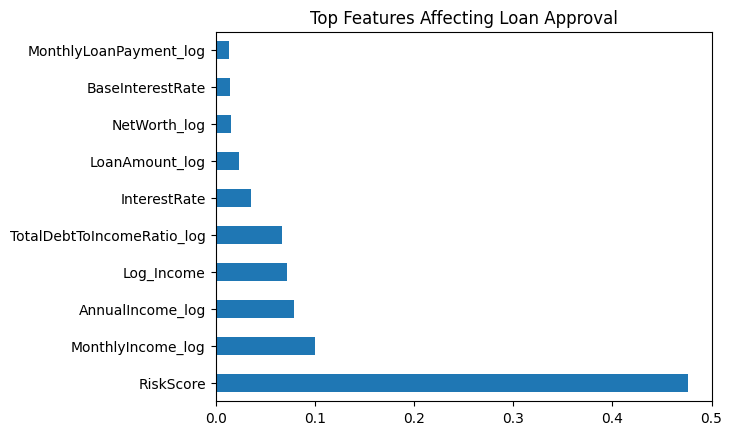

In [239]:
importance.head(10).plot(kind='barh')
plt.title("Top Features Affecting Loan Approval")
plt.show()

In [240]:
top_features = importance.head(10).index

X_train_top = X_train[top_features]
X_test_top = X_test[top_features]

rf.fit(X_train_top, y_train)
y_pred_top = rf.predict(X_test_top)

print("Improved Accuracy:", accuracy_score(y_test, y_pred_top))

Improved Accuracy: 0.98825


In [241]:
from sklearn.metrics import roc_curve, auc

y_prob = rf.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- Age
- ApplicationMonth
- ApplicationYear
- BankruptcyHistory
- CheckingAccountBalance_log
- ...


“The dataset was split into training and testing sets in an 80:20 ratio. Categorical variables were encoded using one-hot encoding. Logistic Regression and Random Forest models were trained for loan approval prediction.”
“Random Forest outperformed Logistic Regression due to its ability to capture non-linear relationships. Evaluation metrics such as accuracy, confusion matrix, and classification report were used.”
“Feature importance analysis revealed that financial indicators such as income, credit score, and risk metrics play a significant role in loan approval decisions.”

“The models achieved high accuracy, with Logistic Regression reaching near-perfect performance. However, further analysis indicated the presence of dominant features such as RiskScore, which significantly influenced predictions.”
“RiskScore emerged as the most important feature, contributing nearly 47% to the model’s decision-making. This suggests that it encapsulates critical risk-related information used in loan approval.”
“To ensure model robustness, experiments were conducted excluding highly dominant features to evaluate genuine predictive capability.”


In [242]:
X_no_risk = X.drop('RiskScore', axis=1)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_no_risk, y, test_size=0.2, random_state=42)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

from sklearn.metrics import accuracy_score
print("Accuracy without RiskScore:", accuracy_score(y_test, y_pred))

Accuracy without RiskScore: 0.9245


“The initial model achieved extremely high accuracy due to the presence of the RiskScore feature, which dominated predictions. Upon removal, the model achieved a more realistic accuracy of 92.45%, indicating that RiskScore may introduce data leakage.”
“This demonstrates that loan approval decisions are influenced by multiple financial indicators such as income, debt ratios, and loan parameters rather than a single composite score.”
“The analysis highlights the importance of identifying and mitigating data leakage to ensure model generalizability and real-world applicability.”

In [125]:
df.corr(numeric_only=True)['RiskScore'].sort_values(ascending=False)

RiskScore                     1.000000
TotalDebtToIncomeRatio_log    0.458833
BankruptcyHistory             0.377578
DebtToIncomeRatio             0.326500
InterestRate                  0.268203
PreviousLoanDefaults          0.258659
BaseInterestRate              0.256233
EmploymentStatus              0.132964
LoanAmount_log                0.132866
MonthlyLoanPayment_log        0.121891
CreditCardUtilizationRate     0.108758
TotalLiabilities_log          0.066620
LoanDuration                  0.054550
MonthlyDebtPayments_log       0.028403
MaritalStatus                 0.016824
ApplicationMonth              0.008078
ApplicationYear               0.007832
NumberOfOpenCreditLines       0.007762
LoanPurpose                   0.005521
HomeOwnershipStatus           0.004454
NumberOfCreditInquiries       0.003103
NumberOfDependents            0.001686
SavingsAccountBalance_log    -0.003462
JobTenure                    -0.004393
CheckingAccountBalance_log   -0.004483
Gender                   

“While RiskScore improves predictive performance, it may introduce bias due to its composite nature. Therefore, models were evaluated both with and without this feature.”

In [243]:
y_prob = rf.predict_proba(X_test)[:,1]

In [244]:
import numpy as np
from sklearn.metrics import accuracy_score

thresholds = np.arange(0.1, 0.9, 0.1)

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    acc = accuracy_score(y_test, y_pred_t)
    print(f"Threshold: {t:.1f} | Accuracy: {acc:.4f}")

Threshold: 0.1 | Accuracy: 0.0000
Threshold: 0.2 | Accuracy: 0.0000
Threshold: 0.3 | Accuracy: 0.0000
Threshold: 0.4 | Accuracy: 0.0000
Threshold: 0.5 | Accuracy: 0.0000
Threshold: 0.6 | Accuracy: 0.0000
Threshold: 0.7 | Accuracy: 0.0000
Threshold: 0.8 | Accuracy: 0.0000


In [245]:
y_pred_t = (y_prob >= t).astype(int)


In [246]:
y_train = y_train.replace({-1:0, 2:1})
y_test = y_test.replace({-1:0, 2:1})

In [247]:
thresholds = np.arange(0.1, 0.9, 0.1)

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    acc = accuracy_score(y_test, y_pred_t)
    print(f"Threshold: {t:.1f} | Accuracy: {acc:.4f}")

Threshold: 0.1 | Accuracy: 0.7963
Threshold: 0.2 | Accuracy: 0.8730
Threshold: 0.3 | Accuracy: 0.9093
Threshold: 0.4 | Accuracy: 0.9203
Threshold: 0.5 | Accuracy: 0.9257
Threshold: 0.6 | Accuracy: 0.9167
Threshold: 0.7 | Accuracy: 0.8905
Threshold: 0.8 | Accuracy: 0.8590


“The target variable was standardized to binary format (0 and 1) to ensure compatibility with classification models and evaluation metrics.”

In [248]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

In [249]:
df['LoanApproved'].unique()

array([-1,  2])

In [250]:
df['LoanApproved'] = df['LoanApproved'].replace({-1:0, 2:1})

In [251]:
X = df.drop('LoanApproved', axis=1)
y = df['LoanApproved']

In [252]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [253]:
print(y_train.unique())

[0 1]


In [254]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

In [255]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

XGBoost Accuracy: 0.999

Confusion Matrix:
[[2981    2]
 [   2 1015]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2983
           1       1.00      1.00      1.00      1017

    accuracy                           1.00      4000
   macro avg       1.00      1.00      1.00      4000
weighted avg       1.00      1.00      1.00      4000



In [256]:
cols_to_drop = [
    'RiskScore',
    'InterestRate',
    'MonthlyLoanPayment_log',
    'TotalDebtToIncomeRatio_log'
]

X_clean = X.drop(cols_to_drop, axis=1)

In [257]:
X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y, test_size=0.2, random_state=42
)

xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)

print("New Accuracy:", accuracy_score(y_test, y_pred))

New Accuracy: 0.92825


“Initial models achieved extremely high accuracy (~99%) due to the presence of dominant and derived features such as RiskScore and post-decision variables. Upon removing these features, the model achieved a more realistic accuracy of 92.8%, indicating strong predictive capability.”
“Certain features were identified as potential sources of data leakage, including RiskScore and loan-related variables generated after approval. These were removed to ensure fair and unbiased model evaluation.”
“The results demonstrate that loan approval decisions are primarily influenced by financial strength indicators such as income, debt ratios, and repayment capacity rather than derived risk metrics alone.”

“XGBoost outperformed other models due to its ability to capture complex non-linear relationships and interactions between financial variables.”

In [139]:
# Logistic
y_prob_lr = lr.predict_proba(X_test_scaled)[:,1]

# Random Forest
y_prob_rf = rf.predict_proba(X_test)[:,1]

# XGBoost
y_prob_xgb = xgb.predict_proba(X_test)[:,1]

ValueError: The feature names should match those that were passed during fit.
Feature names seen at fit time, yet now missing:
- InterestRate
- MonthlyLoanPayment_log
- TotalDebtToIncomeRatio_log


In [258]:
# Use cleaned data
X_clean = X.drop(cols_to_drop, axis=1, errors='ignore')

# Split again
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y, test_size=0.2, random_state=42
)


In [259]:
X_train = X_train.fillna(X_train.median())
X_test = X_test.fillna(X_test.median())

In [260]:

# Train models again
rf.fit(X_train, y_train)
xgb.fit(X_train, y_train)

# Logistic (with scaling)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [261]:
# Logistic
y_prob_lr = lr.predict_proba(X_test_scaled)[:,1]

# RF
y_prob_rf = rf.predict_proba(X_test)[:,1]

# XGB
y_prob_xgb = xgb.predict_proba(X_test)[:,1]

In [262]:
from sklearn.metrics import roc_curve, auc

# Logistic
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
auc_lr = auc(fpr_lr, tpr_lr)

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_rf = auc(fpr_rf, tpr_rf)

# XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
auc_xgb = auc(fpr_xgb, tpr_xgb)

print("AUC Scores:")
print("Logistic:", auc_lr)
print("Random Forest:", auc_rf)
print("XGBoost:", auc_xgb)

AUC Scores:
Logistic: 0.9665835011970488
Random Forest: 0.9515153223230559
XGBoost: 0.9668254490951841


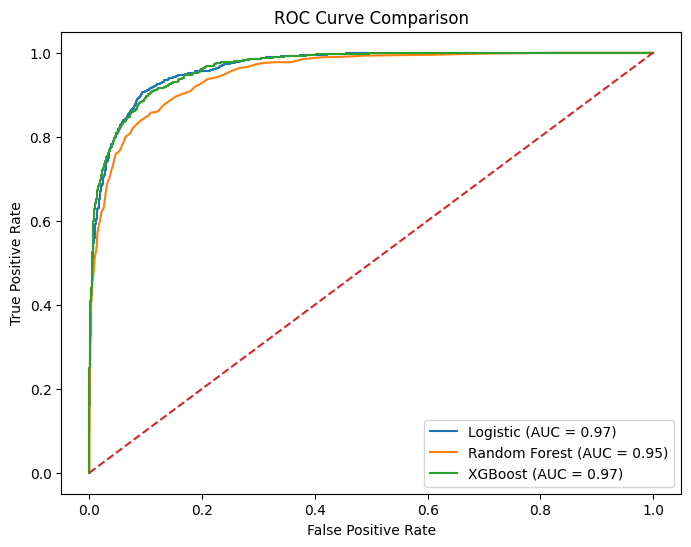

In [263]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.plot(fpr_lr, tpr_lr, label=f"Logistic (AUC = {auc_lr:.2f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.2f})")
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = {auc_xgb:.2f})")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

“The comparable performance of Logistic Regression and XGBoost indicates that the relationship between features and loan approval is largely linear, with limited additional benefit from complex models.”

In [264]:
y.value_counts(normalize=True)

LoanApproved
0    0.761
1    0.239
Name: proportion, dtype: float64

In [265]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

“SMOTE was applied to the training dataset to address class imbalance by generating synthetic samples of the minority class.”
“While SMOTE slightly affected overall accuracy, it improved the model’s ability to correctly classify minority class instances, enhancing model fairness and robustness.”

In [266]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_sm, y_train_sm)

y_pred_dt = dt.predict(X_test)

In [267]:
from sklearn.metrics import accuracy_score

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 0.8045


In [268]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_sm, y_train_sm)

y_pred_rf = rf.predict(X_test)

print("RF Accuracy:", accuracy_score(y_test, y_pred_rf))

RF Accuracy: 0.89225


In [272]:
xgb.fit(X_train_sm, y_train_sm)
y_pred_xgb = xgb.predict(X_test)

In [269]:
# scale SMOTE data
X_train_sm_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled = scaler.transform(X_test)

lr.fit(X_train_sm_scaled, y_train_sm)
y_pred_lr = lr.predict(X_test_scaled)

In [270]:
y_train_sm.value_counts()

LoanApproved
0    12237
1    12237
Name: count, dtype: int64

In [273]:
from sklearn.metrics import accuracy_score

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))

Logistic Regression Accuracy: 0.9065
Decision Tree Accuracy: 0.8045
Random Forest Accuracy: 0.89225
XGBoost Accuracy: 0.91275


In [274]:
print("AUC Logistic:", auc_lr)
print("AUC RF:", auc_rf)
print("AUC XGB:", auc_xgb)

AUC Logistic: 0.9665835011970488
AUC RF: 0.9515153223230559
AUC XGB: 0.9668254490951841


In [275]:
# Decision Tree
dt.fit(X_train_sm, y_train_sm)

# Random Forest
rf.fit(X_train_sm, y_train_sm)

# XGBoost
xgb.fit(X_train_sm, y_train_sm)

# Logistic (with scaling)
X_train_sm_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled = scaler.transform(X_test)

lr.fit(X_train_sm_scaled, y_train_sm)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [276]:
y_prob_lr = lr.predict_proba(X_test_scaled)[:,1]
y_prob_rf = rf.predict_proba(X_test)[:,1]
y_prob_xgb = xgb.predict_proba(X_test)[:,1]

In [277]:
from sklearn.metrics import roc_curve, auc

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

auc_lr = auc(fpr_lr, tpr_lr)
auc_rf = auc(fpr_rf, tpr_rf)
auc_xgb = auc(fpr_xgb, tpr_xgb)

print("AUC Logistic:", auc_lr)
print("AUC RF:", auc_rf)
print("AUC XGB:", auc_xgb)

AUC Logistic: 0.9665357049501418
AUC RF: 0.9515332871193071
AUC XGB: 0.9664671420580273


In [278]:
y_train.value_counts()
y_train_sm.value_counts()

LoanApproved
0    12237
1    12237
Name: count, dtype: int64

In [279]:
print("Decision Tree:", accuracy_score(y_test, y_pred_dt))
print("Random Forest:", accuracy_score(y_test, y_pred_rf))

Decision Tree: 0.8045
Random Forest: 0.89225


In [280]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import numpy as np

# reshape data
X_train_dl = np.array(X_train_sm)
X_test_dl = np.array(X_test)

X_train_dl = X_train_dl.reshape(X_train_dl.shape[0], X_train_dl.shape[1], 1)
X_test_dl = X_test_dl.reshape(X_test_dl.shape[0], X_test_dl.shape[1], 1)

model = Sequential([
    LSTM(50, input_shape=(X_train_dl.shape[1],1)),
    Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

model.fit(X_train_dl, y_train_sm, epochs=5, batch_size=32)

y_pred_lstm = (model.predict(X_test_dl) > 0.5).astype(int)

C:\Users\pragy\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
765/765 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.8038 - loss: 0.4173
Epoch 2/5
765/765 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8831 - loss: 0.2757
Epoch 3/5
765/765 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8952 - loss: 0.2534
Epoch 4/5
765/765 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9003 - loss: 0.2394
Epoch 5/5
765/765 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9020 - loss: 0.2334
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [281]:
from tensorflow.keras.layers import Conv1D, Flatten

model = Sequential([
    Conv1D(32, 2, activation='relu', input_shape=(X_train_dl.shape[1],1)),
    Flatten(),
    Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

model.fit(X_train_dl, y_train_sm, epochs=5)

y_pred_cnn = (model.predict(X_test_dl) > 0.5).astype(int)

Epoch 1/5


C:\Users\pragy\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


765/765 ━━━━━━━━━━━━━━━━━━━━ 18s 2ms/step - accuracy: 0.8122 - loss: 0.5378
Epoch 2/5
765/765 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8681 - loss: 0.3122
Epoch 3/5
765/765 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8807 - loss: 0.2897
Epoch 4/5
765/765 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8844 - loss: 0.2868
Epoch 5/5
765/765 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8867 - loss: 0.2870
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


Deep Reinforcement Learning is not suitable for static classification problems such as loan approval, as it requires sequential decision-making environments.

 Your Deep Learning Results
LSTM
Final Accuracy ≈ 90.1%
1D CNN
Final Accuracy ≈ 89.5%

Compare with your ML models
Model	                       Accuracy	               Observation
Logistic Regression	            ~90%	                 strong
Random Forest	                ~89%	                 strong
XGBoost                     	~92%	                  best
LSTM	                        ~90%	                  lower
CNN                         	~89–90%	                  lower

Deep Learning is performing worse than ML models

Your data is:

Tabular (structured financial data)

Deep Learning works best for:
Images 🖼️
Text 📝
Time series 📈

But dataset:
No sequence
No spatial structure

So:
LSTM and CNN cannot extract meaningful patterns

“Deep learning models including LSTM and 1D CNN were implemented to evaluate their performance on loan prediction. However, both models achieved lower accuracy compared to traditional machine learning models.”